# Algorithmic Monoculture in Machine Learning-Based Site-Specific Fertilizer Recommendation

## Reproducibility notebook

This notebook reproduces the empirical calibration and counterfactual analysis reported in the accompanying paper.

The workflow uses Fertimap-derived fertilizer recommendation resources made available through the independent Turba Open Lab ecosystem. The `turba-data` package provides the analysis-ready Fertimap extract, while `turba-models` provides pretrained models and the cross-model benchmark used for calibration.

The notebook does not retrain the fertilizer recommendation models. Reported model benchmark performance is converted into a dimensionless predictive risk measure and used to evaluate alternative model adoption policies under the economic framework developed in the paper.

# 1. Environment and dependencies

The analysis requires standard scientific Python packages together with the public `turba-data` and `turba-models` packages. No manual dataset upload is required.

In [21]:
%pip install -q turba-data turba-models numpy pandas scipy matplotlib

Note: you may need to restart the kernel to use updated packages.


## 1.1 Imports and global configuration

In [22]:
from dataclasses import dataclass
from pathlib import Path
from typing import Iterable

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import Bounds, LinearConstraint, minimize

import turba_data as td
import turba_models as tm

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:.6f}")

# 2. Economic model and analysis functions

This section implements the loss function, adoption policies, analytical threshold, portfolio optimization problem, and sensitivity analysis used in the paper.

For each model, predictive risk is decomposed into a model-specific common component and a farm-specific component. Adoption concentration affects the common component through squared model adoption shares.

## 2.1 Scenario definition and predictive risk construction

For a crop \(c\), model \(m\), and nutrient target \(t\), the benchmark risk is

$$
r_{cm} = \frac{1}{3}\sum_{t \in \{N,P_2O_5,K_2O\}} \left(1-R^2_{cmt}\right)
$$

For a common fixed test set, \(1-R^2\) is the sum of squared prediction errors normalized by total target variation. Averaging this quantity across NPK outputs gives a dimensionless multi-output risk measure.

In [23]:
TARGETS = (
    "recommended_n",
    "recommended_p2o5",
    "recommended_k2o",
)


@dataclass(frozen=True)
class Scenario:
    common_share: float = 0.25
    externality_weight: float = 20.0
    population: int = 10_000
    private_regret_cap: float = 0.10
    top_k: int = 3


def load_leaderboard(source: str | Path) -> pd.DataFrame:
    """Load and validate the Turba cross-model benchmark."""
    frame = pd.read_csv(source)
    required = {"crop_name", "model_name", "target", "R2", "RMSE"}
    missing = required.difference(frame.columns)

    if missing:
        raise ValueError(f"Missing required columns: {sorted(missing)}")

    return frame


def risk_table(leaderboard: pd.DataFrame) -> pd.DataFrame:
    """Construct crop-model predictive risk from target-level R-squared values."""
    frame = leaderboard.loc[
        leaderboard["target"].isin(TARGETS)
    ].copy()

    if frame.empty:
        raise ValueError("No NPK target rows found in the benchmark.")

    frame["target_risk"] = 1.0 - frame["R2"].astype(float)

    out = (
        frame.groupby(["crop_name", "model_name"], as_index=False)
        .agg(
            private_risk=("target_risk", "mean"),
            mean_r2=("R2", "mean"),
            mean_rmse=("RMSE", "mean"),
        )
    )

    out["private_risk"] = out["private_risk"].clip(lower=1e-12)
    out = out.sort_values(
        ["crop_name", "private_risk", "model_name"]
    ).reset_index(drop=True)

    out["rank"] = (
        out.groupby("crop_name")["private_risk"]
        .rank(method="first")
    )

    return out

## 2.2 Loss function and adoption policies

The private component depends on average predictive risk. The systemic component penalizes aggregate prescription error and gives additional weight to model-specific common error when adoption is concentrated.

In [24]:
def hhi(shares: np.ndarray) -> float:
    """Herfindahl-Hirschman Index of model adoption shares."""
    shares = np.asarray(shares, dtype=float)
    return float(np.dot(shares, shares))


def expected_loss(
    shares: np.ndarray,
    risks: np.ndarray,
    common_share: float,
    externality_weight: float,
    population: int,
) -> dict[str, float]:
    """Compute private, systemic, and total normalized social loss."""
    q = np.asarray(shares, dtype=float)
    r = np.asarray(risks, dtype=float)

    if not np.isclose(q.sum(), 1.0, atol=1e-7):
        raise ValueError("Adoption shares must sum to one.")

    if np.any(q < -1e-10):
        raise ValueError("Adoption shares must be nonnegative.")

    rho = float(common_share)
    lam = float(externality_weight)
    n = int(population)

    if not 0 <= rho <= 1:
        raise ValueError("common_share must lie in [0, 1].")

    if lam < 0 or n <= 0:
        raise ValueError("Invalid externality weight or population.")

    mean_risk = float(np.dot(q, r))
    private_loss = 0.5 * mean_risk
    common_risk = float(np.dot(q * q, r))

    systemic_loss = 0.5 * lam * (
        rho * common_risk
        + (1.0 - rho) * mean_risk / n
    )

    return {
        "private_loss": private_loss,
        "systemic_loss": systemic_loss,
        "social_loss": private_loss + systemic_loss,
        "mean_private_risk": mean_risk,
        "hhi": hhi(q),
    }


def best_monoculture(risks: np.ndarray) -> np.ndarray:
    """Assign all adoption to the lowest-risk model."""
    r = np.asarray(risks, dtype=float)
    q = np.zeros_like(r)
    q[int(np.argmin(r))] = 1.0
    return q


def uniform_portfolio(risks: np.ndarray) -> np.ndarray:
    """Assign equal adoption shares across candidate models."""
    r = np.asarray(risks, dtype=float)
    return np.ones_like(r) / len(r)

## 2.3 Accuracy-constrained portfolio optimization

The diversity-aware policy minimizes modeled social loss subject to

$$
\sum_m q_m r_m \leq (1+\delta)r_{\min}
$$

The regret cap prevents diversification from being achieved through large deterioration in predictive quality.

In [25]:
def optimize_portfolio(
    risks: np.ndarray,
    common_share: float,
    externality_weight: float,
    population: int,
    private_regret_cap: float | None = None,
) -> np.ndarray:
    """Solve the convex model-adoption portfolio problem."""
    r = np.asarray(risks, dtype=float)
    k = len(r)
    best = float(r.min())

    if float(externality_weight) == 0.0 or float(common_share) == 0.0:
        return best_monoculture(r)

    rho = float(common_share)
    lam = float(externality_weight)
    n = int(population)

    linear = 0.5 * (1.0 + lam * (1.0 - rho) / n) * r
    quadratic = 0.5 * lam * rho * r

    def objective(q: np.ndarray) -> float:
        return float(np.dot(linear, q) + np.dot(quadratic, q * q))

    def gradient(q: np.ndarray) -> np.ndarray:
        return linear + 2.0 * quadratic * q

    def hessian(q: np.ndarray) -> np.ndarray:
        return np.diag(2.0 * quadratic)

    cap = (
        None
        if private_regret_cap is None
        else (1.0 + float(private_regret_cap)) * best
    )

    constraints = [
        {"type": "eq", "fun": lambda q: np.sum(q) - 1.0}
    ]

    if cap is not None:
        constraints.append(
            {
                "type": "ineq",
                "fun": lambda q, cap=cap: cap - np.dot(q, r),
            }
        )

    x0 = best_monoculture(r)

    result = minimize(
        objective,
        x0,
        jac=gradient,
        method="SLSQP",
        bounds=[(0.0, 1.0)] * k,
        constraints=constraints,
        options={"ftol": 1e-12, "maxiter": 300, "disp": False},
    )

    feasible = (
        result.x is not None
        and abs(np.sum(result.x) - 1.0) <= 1e-6
        and np.min(result.x) >= -1e-7
    )

    if feasible and cap is not None:
        feasible = np.dot(result.x, r) <= cap + 1e-7

    if not result.success and not feasible:
        linear_constraints = [
            LinearConstraint(
                np.ones((1, k)),
                np.array([1.0]),
                np.array([1.0]),
            )
        ]

        if cap is not None:
            linear_constraints.append(
                LinearConstraint(
                    r.reshape(1, -1),
                    np.array([-np.inf]),
                    np.array([cap]),
                )
            )

        result = minimize(
            objective,
            x0,
            jac=gradient,
            hess=hessian,
            method="trust-constr",
            bounds=Bounds(np.zeros(k), np.ones(k)),
            constraints=linear_constraints,
            options={
                "gtol": 1e-9,
                "xtol": 1e-9,
                "maxiter": 500,
                "verbose": 0,
            },
        )

    if result.x is None:
        raise RuntimeError(result.message)

    q = np.clip(result.x, 0.0, 1.0)
    q = q / q.sum()

    return q

## 2.4 Analytical threshold and crop-level evaluation

The two-model threshold gives the minimum externality weight above which a marginal shift away from the privately best model lowers modeled social loss.

In [26]:
def two_model_threshold(
    r1: float,
    r2: float,
    common_share: float,
    population: int = 10_000,
) -> float:
    """Externality threshold for beneficial marginal diversification."""
    if r2 <= r1:
        raise ValueError("r2 must exceed r1.")

    rho = float(common_share)
    delta = float(r2 - r1)

    denominator = (
        2.0 * rho * r1
        - (1.0 - rho) * delta / int(population)
    )

    if denominator <= 0:
        return float("inf")

    return delta / denominator


def two_model_optimal_share(
    r1: float,
    r2: float,
    common_share: float,
    externality_weight: float,
    population: int = 10_000,
) -> float:
    """Closed-form unconstrained share assigned to the second model."""
    rho = float(common_share)
    lam = float(externality_weight)
    n = int(population)
    delta = float(r2 - r1)

    if lam <= 0 or rho <= 0:
        return 0.0

    numerator = (
        2.0 * lam * rho * r1
        - delta * (1.0 + lam * (1.0 - rho) / n)
    )

    denominator = 2.0 * lam * rho * (r1 + r2)

    return float(np.clip(numerator / denominator, 0.0, 1.0))


def candidate_models(
    risks: pd.DataFrame,
    crop: str,
    top_k: int = 3,
) -> pd.DataFrame:
    """Return the lowest-risk candidate models for one crop."""
    group = (
        risks.loc[risks["crop_name"] == crop]
        .sort_values("private_risk")
        .head(top_k)
        .copy()
    )

    if group.empty:
        raise KeyError(crop)

    return group.reset_index(drop=True)


def crop_analysis(
    risks: pd.DataFrame,
    scenario: Scenario,
) -> tuple[pd.DataFrame, pd.DataFrame]:
    """Evaluate all adoption policies for every crop system."""
    summary_rows = []
    share_rows = []

    for crop in sorted(risks["crop_name"].unique()):
        candidates = candidate_models(risks, crop, scenario.top_k)
        model_names = candidates["model_name"].to_numpy()
        r = candidates["private_risk"].to_numpy(dtype=float)

        policies = {
            "best_monoculture": best_monoculture(r),
            "uniform_top_models": uniform_portfolio(r),
            "diversity_aware": optimize_portfolio(
                r,
                scenario.common_share,
                scenario.externality_weight,
                scenario.population,
                scenario.private_regret_cap,
            ),
            "unconstrained_social": optimize_portfolio(
                r,
                scenario.common_share,
                scenario.externality_weight,
                scenario.population,
                None,
            ),
        }

        monoculture_loss = expected_loss(
            policies["best_monoculture"],
            r,
            scenario.common_share,
            scenario.externality_weight,
            scenario.population,
        )["social_loss"]

        for policy, q in policies.items():
            metrics = expected_loss(
                q,
                r,
                scenario.common_share,
                scenario.externality_weight,
                scenario.population,
            )

            summary_rows.append(
                {
                    "crop_name": crop,
                    "policy": policy,
                    **metrics,
                    "social_loss_reduction_vs_monoculture_pct":
                        100.0
                        * (monoculture_loss - metrics["social_loss"])
                        / monoculture_loss,
                }
            )

            for model_name, share, risk in zip(model_names, q, r):
                share_rows.append(
                    {
                        "crop_name": crop,
                        "policy": policy,
                        "model_name": model_name,
                        "share": float(share),
                        "private_risk": float(risk),
                    }
                )

    return pd.DataFrame(summary_rows), pd.DataFrame(share_rows)


def sensitivity_grid(
    risks: pd.DataFrame,
    common_shares: Iterable[float],
    externality_weights: Iterable[float],
    regret_caps: Iterable[float],
    population: int = 10_000,
    top_k: int = 3,
) -> pd.DataFrame:
    """Evaluate the diversity-aware policy across the sensitivity grid."""
    rows = []

    for rho in common_shares:
        for lam in externality_weights:
            for delta in regret_caps:
                scenario = Scenario(
                    common_share=rho,
                    externality_weight=lam,
                    population=population,
                    private_regret_cap=delta,
                    top_k=top_k,
                )

                summary, _ = crop_analysis(risks, scenario)

                part = summary.loc[
                    summary["policy"] == "diversity_aware"
                ].copy()

                part["common_share"] = rho
                part["externality_weight"] = lam
                part["private_regret_cap"] = delta
                rows.append(part)

    return pd.concat(rows, ignore_index=True)


def theorem_equal_risk_loss(
    hhi_value: float,
    risk: float,
    scenario: Scenario,
) -> float:
    """Closed-form social loss under equal predictive risk."""
    return 0.5 * risk * (
        1.0
        + scenario.externality_weight
        * (
            scenario.common_share * hhi_value
            + (1.0 - scenario.common_share) / scenario.population
        )
    )

# 3. Public Turba resources

## 3.1 Load the Fertimap-derived Turba dataset

The site-level dataset is loaded directly through `turba-data`. This step verifies public data accessibility and provenance. The paper's cross-model calibration is based on the model benchmark loaded in the next subsection rather than on model retraining in this notebook.

In [27]:
DATASET_ID = "esa_worldcereal_morocco_cereals_medium"

live = td.load_dataset(DATASET_ID)

print("Turba dataset loaded")
print("Rows and columns:", live.shape)
print("Columns:", list(live.columns))

if "site_id" in live.columns:
    print("Unique sites:", live["site_id"].nunique())

display(live.head())

Turba dataset loaded
Rows and columns: (132017, 22)
Columns: ['source', 'longitude', 'latitude', 'region', 'province', 'commune', 'worldcereal_state', 'fertimap_crop_id', 'fertimap_crop_name', 'worldcereal_crop_label', 'soil_type', 'soil_texture', 'soil_ph', 'organic_matter_pct', 'available_p2o5', 'available_k2o', 'target_yield_level', 'target_yield_value', 'target_yield_unit', 'recommended_n', 'recommended_p2o5', 'recommended_k2o']


,source,longitude,latitude,region,province,commune,worldcereal_state,fertimap_crop_id,fertimap_crop_name,worldcereal_crop_label,soil_type,soil_texture,soil_ph,organic_matter_pct,available_p2o5,available_k2o,target_yield_level,target_yield_value,target_yield_unit,recommended_n,recommended_p2o5,recommended_k2o
0,esa_worldcereal,-1.664300,32.498900,Oriental,Figuig,Bni Guil,Oriental,1,Wheat (Rainfed),Winter Cereals,,,0.000000,0.000000,0.000000,0.000000,medium,40.000000,qx/ha,142.670000,88.670000,165.330000
1,esa_worldcereal,-1.664300,32.498900,Oriental,Figuig,Bni Guil,Oriental,2,Wheat (Irrigated),Winter Cereals,,,0.000000,0.000000,0.000000,0.000000,medium,55.000000,qx/ha,190.670000,110.670000,197.330000
2,esa_worldcereal,-1.664300,32.498900,Oriental,Figuig,Bni Guil,Oriental,3,Barley (Rainfed),Winter Cereals,,,0.000000,0.000000,0.000000,0.000000,medium,25.000000,qx/ha,83.330000,63.330000,123.330000
3,esa_worldcereal,-1.701900,32.330700,Oriental,Figuig,Bni Guil,Oriental,1,Wheat (Rainfed),Winter Cereals,,,0.000000,0.000000,0.000000,0.000000,medium,40.000000,qx/ha,142.670000,88.670000,165.330000
4,esa_worldcereal,-1.701900,32.330700,Oriental,Figuig,Bni Guil,Oriental,2,Wheat (Irrigated),Winter Cereals,,,0.000000,0.000000,0.000000,0.000000,medium,55.000000,qx/ha,190.670000,110.670000,197.330000


## 3.2 Inspect published Turba models

The package registry provides the pretrained models currently exposed by `turba-models`. The paper does not retrain these models.

In [28]:
published_models = pd.DataFrame(tm.list_models())

print("Published Turba models")
display(published_models)

Published Turba models


,model_key,crop_name,model_name,task,artifact_path,feature_columns,target_columns,split_policy,metrics_overall
0,barley_rainfed,Barley (Rainfed),LightGBM,direct_npk_recommendation,models/barley-rainfed.joblib,"[longitude, latitude, soil_ph, organic_matter_...","[recommended_n, recommended_p2o5, recommended_...",fixed_deterministic_80_20,"{'R2': 0.9999454003682429, 'MAE': 0.0402128714..."
1,maize_grain,Maize (Grain),XGBoost,direct_npk_recommendation,models/maize-grain.joblib,"[longitude, latitude, soil_ph, organic_matter_...","[recommended_n, recommended_p2o5, recommended_...",fixed_deterministic_80_20,"{'R2': 0.9873768144773866, 'MAE': 0.3854584698..."
2,maize_silage,Maize (Silage),XGBoost,direct_npk_recommendation,models/maize-silage.joblib,"[longitude, latitude, soil_ph, organic_matter_...","[recommended_n, recommended_p2o5, recommended_...",fixed_deterministic_80_20,"{'R2': 0.9942729224818779, 'MAE': 0.4776606499..."
3,wheat_irrigated,Wheat (Irrigated),LightGBM,direct_npk_recommendation,models/wheat-irrigated.joblib,"[longitude, latitude, soil_ph, organic_matter_...","[recommended_n, recommended_p2o5, recommended_...",fixed_deterministic_80_20,"{'R2': 0.9999606530374828, 'MAE': 0.0693348108..."
4,wheat_rainfed,Wheat (Rainfed),LightGBM,direct_npk_recommendation,models/wheat-rainfed.joblib,"[longitude, latitude, soil_ph, organic_matter_...","[recommended_n, recommended_p2o5, recommended_...",fixed_deterministic_80_20,"{'R2': 0.9999339421568787, 'MAE': 0.0577743902..."


## 3.3 Load the cross-model benchmark

The current `turba-models` Python API exposes pretrained models but does not expose the complete nine-family comparison table as a package function. The official cross-model report is therefore loaded directly from the public `turba-models` repository.

In [29]:
LEADERBOARD_URL = (
    "https://raw.githubusercontent.com/"
    "open-turba/turba-models/main/reports/"
    "per_crop_model_leaderboard.csv"
)

board = load_leaderboard(LEADERBOARD_URL)

if "index" in board.columns:
    board = board.drop(columns=["index"])

risks = risk_table(board)

print("Benchmark rows:", len(board))
print("Crop systems:", risks["crop_name"].nunique())
print("Model families:", risks["model_name"].nunique())

assert risks["crop_name"].nunique() == 5
assert risks["model_name"].nunique() == 9

display(
    risks.sort_values(["crop_name", "private_risk"])
)

Benchmark rows: 180
Crop systems: 5
Model families: 9


,crop_name,model_name,private_risk,mean_r2,mean_rmse,rank
0,Barley (Rainfed),Random Forest,0.003636,0.996364,0.925437,1.000000
1,Barley (Rainfed),Extra Trees,0.006830,0.993170,1.575166,2.000000
2,Barley (Rainfed),AdaBoost,0.014433,0.985567,1.880055,3.000000
3,Barley (Rainfed),Ridge,0.162098,0.837902,8.118090,4.000000
4,Barley (Rainfed),Linear Regression,0.162101,0.837899,8.117882,5.000000
5,Barley (Rainfed),Elastic Net,0.281260,0.718740,10.911314,6.000000
6,Barley (Rainfed),LightGBM,0.902632,0.097368,19.729839,7.000000
7,Barley (Rainfed),XGBoost,0.902727,0.097273,19.730999,8.000000
8,Barley (Rainfed),CatBoost,0.905409,0.094591,19.756841,9.000000
9,Maize (Grain),AdaBoost,0.037274,0.962726,2.909916,1.000000


## 3.4 Lowest-risk model families by crop

The empirical analysis retains the three model families with the lowest dimensionless predictive risk for each crop system.

In [30]:
top3 = (
    risks.sort_values(["crop_name", "private_risk"])
    .groupby("crop_name", group_keys=False)
    .head(3)
    .copy()
)

display(
    top3[
        [
            "crop_name",
            "model_name",
            "private_risk",
            "mean_r2",
            "mean_rmse",
        ]
    ]
)

,crop_name,model_name,private_risk,mean_r2,mean_rmse
0,Barley (Rainfed),Random Forest,0.003636,0.996364,0.925437
1,Barley (Rainfed),Extra Trees,0.006830,0.993170,1.575166
2,Barley (Rainfed),AdaBoost,0.014433,0.985567,1.880055
9,Maize (Grain),AdaBoost,0.037274,0.962726,2.909916
10,Maize (Grain),Ridge,0.291753,0.708247,11.071849
11,Maize (Grain),Linear Regression,0.349457,0.650543,11.712765
18,Maize (Silage),AdaBoost,0.024021,0.975979,3.201046
19,Maize (Silage),Random Forest,0.120020,0.879980,5.274404
20,Maize (Silage),Ridge,0.296794,0.703206,15.445233
27,Wheat (Irrigated),Random Forest,0.005152,0.994848,1.282068


## 3.5 Figure 1

The figure reports the three lowest-risk model families for each crop system. The horizontal axis uses a logarithmic scale because predictive risk differs substantially across crop benchmarks.

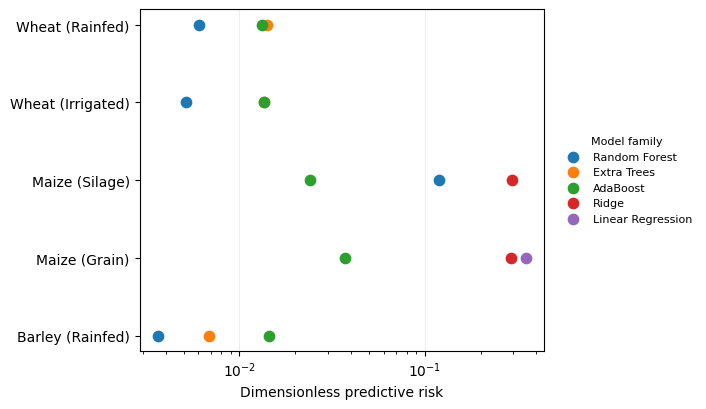

In [31]:
crop_order = [
    "Barley (Rainfed)",
    "Maize (Grain)",
    "Maize (Silage)",
    "Wheat (Irrigated)",
    "Wheat (Rainfed)",
]

ypos = {crop: i for i, crop in enumerate(crop_order)}
model_order = list(top3["model_name"].drop_duplicates())

fig, ax = plt.subplots(figsize=(7.2, 4.2))

for model in model_order:
    subset = top3.loc[top3["model_name"] == model]

    ax.scatter(
        subset["private_risk"],
        subset["crop_name"].map(ypos),
        s=55,
        label=model,
        zorder=3,
    )

ax.set_xscale("log")
ax.set_xlabel("Dimensionless predictive risk")
ax.set_ylabel("")

ax.set_yticks(range(len(crop_order)))
ax.set_yticklabels(crop_order)

ax.grid(axis="x", alpha=0.25, linewidth=0.6)

ax.legend(
    title="Model family",
    frameon=False,
    fontsize=8,
    title_fontsize=8,
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),
)

plt.tight_layout()

plt.savefig(
    "model_risk_by_crop.pdf",
    bbox_inches="tight",
)

plt.savefig(
    "model_risk_by_crop.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

# 4. Formal model verification

## 4.1 Equal-risk concentration result

Under equal predictive risk, modeled social loss is increasing in adoption concentration whenever the common error share and externality weight are positive. Monoculture has HHI equal to one, while uniform adoption across three models has HHI equal to one third.

In [32]:
scenario = Scenario(
    common_share=0.25,
    externality_weight=20.0,
    population=10_000,
    private_regret_cap=0.10,
    top_k=3,
)

shared_risk = 0.02

monoculture_loss = theorem_equal_risk_loss(
    hhi_value=1.0,
    risk=shared_risk,
    scenario=scenario,
)

uniform_loss = theorem_equal_risk_loss(
    hhi_value=1.0 / 3.0,
    risk=shared_risk,
    scenario=scenario,
)

reduction_pct = (
    100.0
    * (monoculture_loss - uniform_loss)
    / monoculture_loss
)

print("Equal-risk monoculture loss:", round(monoculture_loss, 6))
print("Equal-risk uniform portfolio loss:", round(uniform_loss, 6))
print("Reduction percent:", round(reduction_pct, 3))

assert uniform_loss < monoculture_loss

Equal-risk monoculture loss: 0.060015
Equal-risk uniform portfolio loss: 0.026682
Reduction percent: 55.542


## 4.2 Accuracy-monoculture thresholds

For each crop, the two lowest-risk model families are used to calculate the externality threshold above which a marginal shift away from the privately best model lowers modeled social loss.

In [33]:
threshold_rows = []

for crop, group in risks.groupby("crop_name"):
    top = (
        group.sort_values("private_risk")
        .head(2)
        .reset_index(drop=True)
    )

    r1 = float(top.loc[0, "private_risk"])
    r2 = float(top.loc[1, "private_risk"])

    threshold_rows.append(
        {
            "crop_name": crop,
            "best_model": top.loc[0, "model_name"],
            "second_model": top.loc[1, "model_name"],
            "best_risk": r1,
            "second_risk": r2,
            "threshold_lambda": two_model_threshold(
                r1,
                r2,
                scenario.common_share,
                scenario.population,
            ),
        }
    )

thresholds = pd.DataFrame(threshold_rows).sort_values("crop_name")

display(thresholds)

,crop_name,best_model,second_model,best_risk,second_risk,threshold_lambda
0,Barley (Rainfed),Random Forest,Extra Trees,0.003636,0.006830,1.757812
1,Maize (Grain),AdaBoost,Ridge,0.037274,0.291753,13.668416
2,Maize (Silage),AdaBoost,Random Forest,0.024021,0.120020,7.997503
3,Wheat (Irrigated),Random Forest,AdaBoost,0.005152,0.013518,3.248185
4,Wheat (Rainfed),Random Forest,AdaBoost,0.006081,0.013259,2.361540


# 5. Central counterfactual

The central calibration uses a common error share of 0.25, an externality weight of 20, a population normalization of 10,000 farms, a 10 percent private predictive risk regret cap, and the three lowest-risk models per crop.

These parameters are sensitivity assumptions rather than estimates of Moroccan welfare or deployment conditions.

## 5.1 Evaluate adoption policies

Four policies are compared.

1. Best monoculture
2. Uniform adoption across the three candidate models
3. Accuracy-constrained diversity
4. Unconstrained social optimization

In [34]:
central, shares = crop_analysis(risks, scenario)

policy_view = central.loc[
    central["policy"].isin(
        [
            "best_monoculture",
            "uniform_top_models",
            "diversity_aware",
            "unconstrained_social",
        ]
    ),
    [
        "crop_name",
        "policy",
        "mean_private_risk",
        "hhi",
        "private_loss",
        "systemic_loss",
        "social_loss",
        "social_loss_reduction_vs_monoculture_pct",
    ],
]

display(policy_view)

,crop_name,policy,mean_private_risk,hhi,private_loss,systemic_loss,social_loss,social_loss_reduction_vs_monoculture_pct
0,Barley (Rainfed),best_monoculture,0.003636,1.000000,0.001818,0.009091,0.010909,0.000000
1,Barley (Rainfed),uniform_top_models,0.008300,0.333333,0.004150,0.006923,0.011072,-1.494369
2,Barley (Rainfed),diversity_aware,0.003999,0.798312,0.002000,0.007362,0.009362,14.186345
3,Barley (Rainfed),unconstrained_social,0.005456,0.485111,0.002728,0.005263,0.007991,26.752265
4,Maize (Grain),best_monoculture,0.037274,1.000000,0.018637,0.093213,0.111851,0.000000
5,Maize (Grain),uniform_top_models,0.226161,0.333333,0.113081,0.188637,0.301718,-169.750987
6,Maize (Grain),diversity_aware,0.041002,0.971135,0.020501,0.090663,0.111164,0.614074
7,Maize (Grain),unconstrained_social,0.049854,0.910190,0.024927,0.085725,0.110652,1.071616
8,Maize (Silage),best_monoculture,0.024021,1.000000,0.012011,0.060072,0.072082,0.000000
9,Maize (Silage),uniform_top_models,0.146945,0.333333,0.073473,0.122564,0.196037,-171.962367


## 5.2 Central results reported in the paper

In [35]:
diversity = central.loc[
    central["policy"] == "diversity_aware"
].copy()

print(
    "Positive gain crops:",
    int(
        (
            diversity["social_loss_reduction_vs_monoculture_pct"] > 0
        ).sum()
    ),
    "of",
    len(diversity),
)

print(
    "Mean gain percent:",
    round(
        diversity["social_loss_reduction_vs_monoculture_pct"].mean(),
        3,
    ),
)

print(
    "Minimum gain percent:",
    round(
        diversity["social_loss_reduction_vs_monoculture_pct"].min(),
        3,
    ),
)

print(
    "Maximum gain percent:",
    round(
        diversity["social_loss_reduction_vs_monoculture_pct"].max(),
        3,
    ),
)

central_results = diversity[
    [
        "crop_name",
        "mean_private_risk",
        "hhi",
        "social_loss",
        "social_loss_reduction_vs_monoculture_pct",
    ]
].sort_values("crop_name")

display(central_results)

Positive gain crops: 5 of 5
Mean gain percent: 7.106
Minimum gain percent: 0.614
Maximum gain percent: 14.186


,crop_name,mean_private_risk,hhi,social_loss,social_loss_reduction_vs_monoculture_pct
2,Barley (Rainfed),0.003999,0.798312,0.009362,14.186345
6,Maize (Grain),0.041002,0.971135,0.111164,0.614074
10,Maize (Silage),0.026424,0.951207,0.070505,2.187874
14,Wheat (Irrigated),0.005667,0.882708,0.014247,7.846949
18,Wheat (Rainfed),0.006689,0.846360,0.016295,10.695157


## 5.3 Accuracy-constrained model adoption shares

The optimized portfolio is selective rather than uniformly diversified. Models enter the portfolio only when their systemic-risk contribution compensates for their higher private predictive risk under the regret constraint.

In [36]:
share_view = (
    shares.loc[
        shares["policy"] == "diversity_aware"
    ]
    .pivot(
        index="crop_name",
        columns="model_name",
        values="share",
    )
    .fillna(0)
)

display(share_view.round(4))

model_name,AdaBoost,Extra Trees,Linear Regression,Random Forest,Ridge
crop_name,,,,,
Barley (Rainfed),0.000000,0.113800,0.000000,0.886200,0.000000
Maize (Grain),0.985400,0.000000,0.000000,0.000000,0.014600
Maize (Silage),0.975000,0.000000,0.000000,0.025000,0.000000
Wheat (Irrigated),0.031400,0.030100,0.000000,0.938500,0.000000
Wheat (Rainfed),0.063500,0.018900,0.000000,0.917600,0.000000


## 5.4 Uniform diversification diagnostic

Uniform allocation is evaluated separately because diversity is not assumed to be beneficial by itself. Negative values indicate that equal allocation across the candidate models performs worse than best-model monoculture.

In [37]:
uniform_results = central.loc[
    central["policy"] == "uniform_top_models",
    [
        "crop_name",
        "social_loss_reduction_vs_monoculture_pct",
    ],
].sort_values("crop_name")

display(uniform_results)

print(
    "Crop systems where uniform diversity increases loss:",
    int(
        (
            uniform_results["social_loss_reduction_vs_monoculture_pct"] < 0
        ).sum()
    ),
)

,crop_name,social_loss_reduction_vs_monoculture_pct
1,Barley (Rainfed),-1.494369
5,Maize (Grain),-169.750987
9,Maize (Silage),-171.962367
13,Wheat (Irrigated),7.332088
17,Wheat (Rainfed),18.426775


Crop systems where uniform diversity increases loss: 3


# 6. Sensitivity analysis

The sensitivity analysis varies the common error share, externality weight, and private regret cap. The purpose is to test the mechanism across alternative assumptions rather than to estimate structural parameters.

## 6.1 Evaluate the full sensitivity grid

In [38]:
grid = sensitivity_grid(
    risks=risks,
    common_shares=[
        0.05,
        0.10,
        0.25,
        0.50,
        0.75,
    ],
    externality_weights=[
        0,
        1,
        2,
        5,
        10,
        20,
        50,
        100,
    ],
    regret_caps=[
        0.05,
        0.10,
        0.25,
    ],
    population=10_000,
    top_k=3,
)

print("Sensitivity observations:", len(grid))

print(
    "Positive scenario-crop fraction:",
    round(
        (
            grid["social_loss_reduction_vs_monoculture_pct"] > 1e-9
        ).mean(),
        3,
    ),
)

assert len(grid) == 600

Sensitivity observations: 600
Positive scenario-crop fraction: 0.555


## 6.2 Aggregate sensitivity results

The heat map averages modeled social loss reduction across crops and private regret caps for each combination of common error share and externality weight.

In [39]:
heat = (
    grid.groupby(
        ["common_share", "externality_weight"]
    )["social_loss_reduction_vs_monoculture_pct"]
    .mean()
    .unstack()
)

display(heat.round(2))

externality_weight,0,1,2,5,10,20,50,100
common_share,,,,,,,,
0.050000,0.000000,0.000000,0.000000,0.000000,0.030000,1.450000,5.400000,8.170000
0.100000,0.000000,0.000000,0.000000,0.030000,1.450000,4.440000,8.190000,10.140000
0.250000,0.000000,0.000000,0.030000,2.410000,5.420000,8.200000,10.590000,11.510000
0.500000,0.000000,0.030000,1.460000,5.420000,8.200000,10.160000,11.510000,12.000000
0.750000,0.000000,0.560000,3.220000,7.100000,9.470000,10.890000,11.840000,12.170000


## 6.3 Figure 2

Positive values indicate lower modeled social loss under accuracy-constrained diversity relative to universal adoption of the private risk-minimizing model.

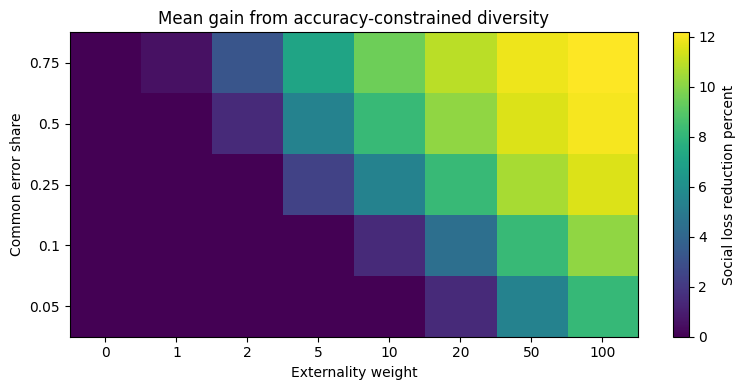

In [40]:
fig, ax = plt.subplots(figsize=(8, 4))

im = ax.imshow(
    heat.values,
    aspect="auto",
    origin="lower",
)

ax.set_xticks(
    range(len(heat.columns)),
    [str(x) for x in heat.columns],
)

ax.set_yticks(
    range(len(heat.index)),
    [str(x) for x in heat.index],
)

ax.set_xlabel("Externality weight")
ax.set_ylabel("Common error share")
ax.set_title("Mean gain from accuracy-constrained diversity")

fig.colorbar(
    im,
    ax=ax,
    label="Social loss reduction percent",
)

plt.tight_layout()

plt.savefig(
    "sensitivity_map.pdf",
    bbox_inches="tight",
)

plt.savefig(
    "sensitivity_map.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()